# LangGraph 입문 데모 노트북

이 노트북은 **상태(state) 기반으로 흘러가는 작은 무대극(stage-play) 그래프**를 아주 단순하게 보여줍니다.

등장 노드:
- `manager`
- `director`
- `character_a`
- `character_b`
- `writer`
- `auditor`

시나리오 전제는 자연스러운 한국어 상황으로 바꿔 두었습니다.

In [1]:
from __future__ import annotations

import asyncio
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

load_dotenv(project_root / '.env')

from src.langgraph_novel_lab.main import build_graph, print_result, run_demo, target_turns

print('project_root =', project_root)
print('model =', os.getenv('OPENAI_MODEL'))
print('target_turns =', target_turns())

project_root = /tmp
model = gpt-4o-mini
target_turns = 4


## 1) 상태와 입력 전제

이번 데모의 전제:

> 비 오는 저녁, 동네 분식집을 함께 살리려는 남매가 마지막 레시피 수첩을 두고 실랑이한다.

LangGraph 쪽 핵심은 **누가 다음에 말할지**를 `next_node`와 `turns`로 결정한다는 점입니다.

In [2]:
premise = "낮에는 화려한 K-팝 아이돌 그룹 '루미너스'로 활동하지만, 밤에는 음악의 주파수를 이용해 도시를 잠식하는 악령들을 사냥하는 데몬 헌터들의 사투와 리더 간의 갈등."

initial_state = {
    'premise': premise,
    'dialogue_history': [],
    'turns': 0,
    'next_node': 'manager',
}

initial_state

{'premise': "낮에는 화려한 K-팝 아이돌 그룹 '루미너스'로 활동하지만, 밤에는 음악의 주파수를 이용해 도시를 잠식하는 악령들을 사냥하는 데몬 헌터들의 사투와 리더 간의 갈등.",
 'dialogue_history': [],
 'turns': 0,
 'next_node': 'manager'}

## 2) 그래프 만들기

이 프로젝트의 그래프는 다음 흐름을 가집니다.

`manager -> director -> character_a <-> character_b -> writer -> auditor`

중요한 점은 `character_a`와 `character_b`가 고정 길이 파이프라인이 아니라, **상태를 보고 라우팅**된다는 것입니다.

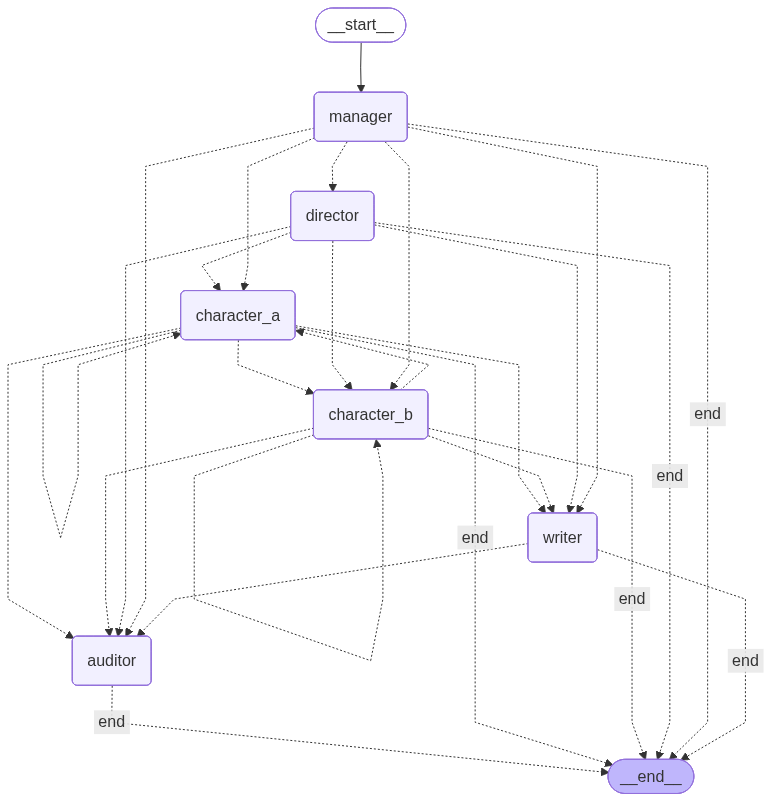

In [3]:
app = build_graph()
app

## 3) 실제 실행

아래 셀은 전체 그래프를 한 번 실행합니다.
출력 로그에서 각 노드가 어떤 순서로 진행되는지 볼 수 있습니다.

In [4]:
result = await run_demo(premise)
print_result(result)

[manager] next_node=director


[director] next_node=character_a


[character_a] turns=1 next_node=character_b


[character_b] turns=2 next_node=character_a


[character_a] turns=3 next_node=character_b


[character_b] turns=4 next_node=writer


[writer] next_node=auditor


[auditor] next_node=end
=== Premise ===
낮에는 화려한 K-팝 아이돌 그룹 '루미너스'로 활동하지만, 밤에는 음악의 주파수를 이용해 도시를 잠식하는 악령들을 사냥하는 데몬 헌터들의 사투와 리더 간의 갈등.

=== Manager Notes ===
**Scene Plan: Confrontation in the Practice Room**

- **Tone**: Tense and dramatic, with an undercurrent of urgency as the group prepares for their dual life. The contrast between their glamorous idol persona and the grim reality of being demon hunters heightens the stakes.

- **Stakes**: The team's next concert is imminent, but they are being pursued by a powerful demon that threatens to expose their secret lives. Failure to eliminate this demon could result in the end of their careers and the safety of their fans.

- **Desired Character Friction**: Tension between the group leader, who prioritizes their idol activities, and a passionate team member advocating for immediate action against the demon. This conflict reveals differing values and approaches to their dual identities, setting the stage for further developments in their rel

## 4) 결과를 구조적으로 보기

노트북에서는 긴 텍스트보다 핵심 필드만 다시 확인하는 게 읽기 쉽습니다.

In [5]:
summary = {
    'next_node': result.get('next_node'),
    'turns': result.get('turns'),
    'dialogue_lines': len(result.get('dialogue_history', [])),
    'audit_present': bool(result.get('audit')),
}
summary

{'next_node': 'end', 'turns': 4, 'dialogue_lines': 4, 'audit_present': True}

In [6]:
result['dialogue_history']

['Character A: 우리가 무대에 서기 전에 이 악령을 처리하지 않으면, 모든 게 끝장나버릴 거야!',
 'Character B: 그렇다고 우리가 팬들을 버릴 수는 없어, 하지만 이 악령이 우리를 찾고 있다는 걸 잊지 마!',
 'Character A: 그렇다면 팬들을 지키면서도 악령을 처치할 방법을 찾아야 해!',
 'Character B: 시간이 없다고, 우리가 무대에 서기 전에 이 악령을 막지 않으면 팬들이 위험해!']

## 5) 학습 포인트

- 상태 객체 하나에 진행 정보가 모입니다.
- 각 노드는 상태 일부만 갱신합니다.
- 다음 노드는 `next_node`와 현재 state를 보고 정해집니다.
- 그래서 **대화 턴 수를 늘리거나**, **캐릭터를 더 추가하거나**, **감수(auditor) 기준을 바꾸는 실험**이 쉽습니다.